In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
df = pd.read_excel("MaizeDataset.xlsx")
df.columns

Index(['County', 'Region', 'State/Province', 'Latitude', 'Longitude',
       'Location reference', 'Evidence', 'Material Dated', 'Lab No.',
       '14C age', '14C age 1σ', 'Sources', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [26]:
df_county = df.groupby('County')

In [27]:
df = pd.DataFrame(columns=['County', '14C age', 'Latitude', 'Longitude'])

for name, group in df_county:
    group.dropna(subset=['Latitude', 'Longitude'], inplace=True)
    if group.shape[0] > 0:
        group['County'] = name
        group['14C age'] = group['14C age'].min()
        df = pd.concat([df, group[['County', '14C age', 'Latitude', 'Longitude']]], ignore_index=True)

df["Year"] = 2000 - df["14C age"]

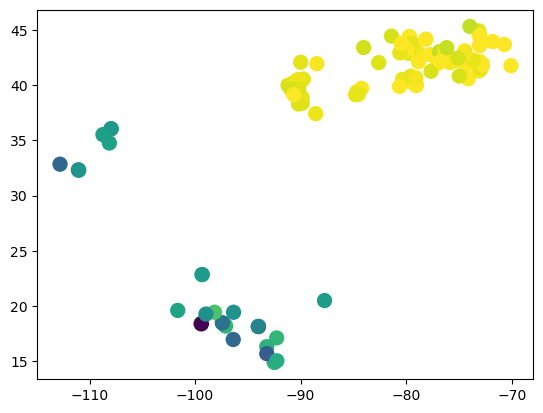

In [28]:
plt.scatter(df["Longitude"], df["Latitude"], c=df["Year"], cmap='viridis', s=100)

In [30]:
df.to_csv("MaizeDataset_cleaned.csv", index=False)